In [1]:
import numpy as np
import pandas as pd
import pingouin as pg

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FIGSIZE = (10, 6)

In [3]:
data = pd.read_csv('data/stroke.csv', index_col='id') #features
data = data.sort_index()
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
67,Female,17.0,0,0,No,Private,Urban,92.97,NaN,formerly smoked,0
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...
72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
72914,Female,19.0,0,0,No,Private,Urban,90.57,24.2,Unknown,0
72915,Female,45.0,0,0,Yes,Private,Urban,172.33,45.3,formerly smoked,0


In [4]:
data.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [5]:
cat_f = list(data.select_dtypes('O')) + list(data.select_dtypes(np.int64))
cat_f.remove('stroke')

con_f = list(data.select_dtypes(np.float64))

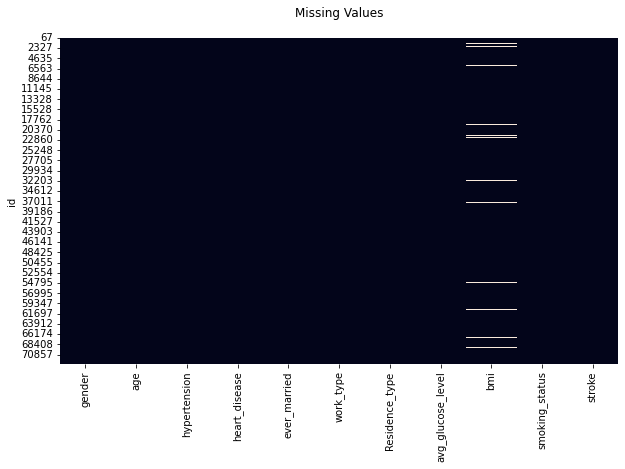

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
plt.figure(figsize=FIGSIZE)
plt.title('Missing Values\n')
sns.heatmap(data.isnull(), cbar=False)
plt.show()

data.isnull().sum()

# Analyse univariée

<br>

C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


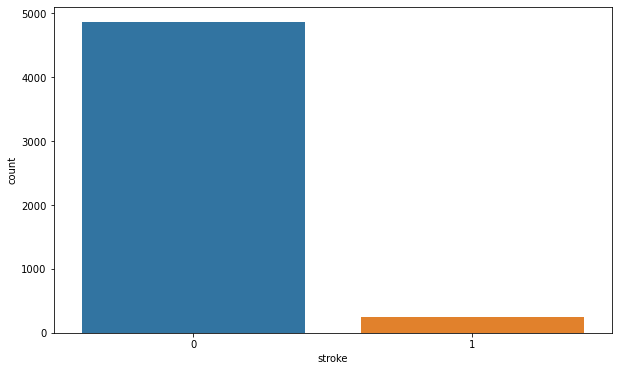

0    0.951272
1    0.048728
Name: stroke, dtype: float64

In [7]:
plt.figure(figsize=FIGSIZE)
sns.countplot(data['stroke'])
plt.show()

data['stroke'].value_counts(normalize=True)

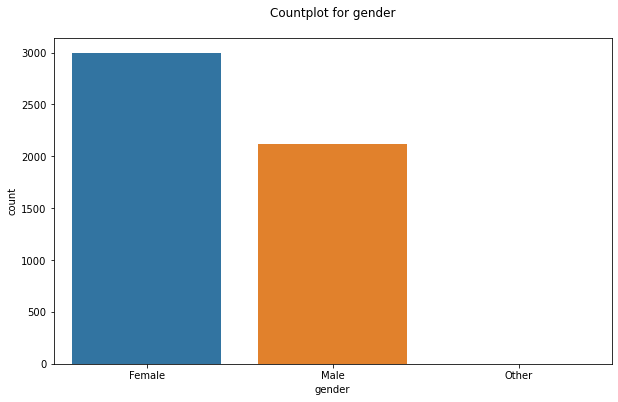

Female    0.585910
Male      0.413894
Other     0.000196
Name: gender, dtype: float64

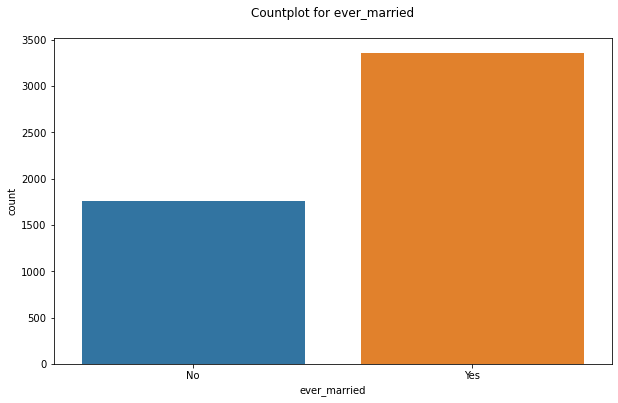

Yes    0.656164
No     0.343836
Name: ever_married, dtype: float64

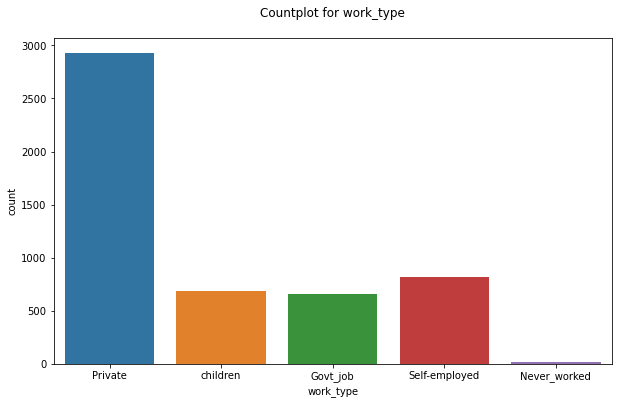

Private          0.572407
Self-employed    0.160274
children         0.134442
Govt_job         0.128571
Never_worked     0.004305
Name: work_type, dtype: float64

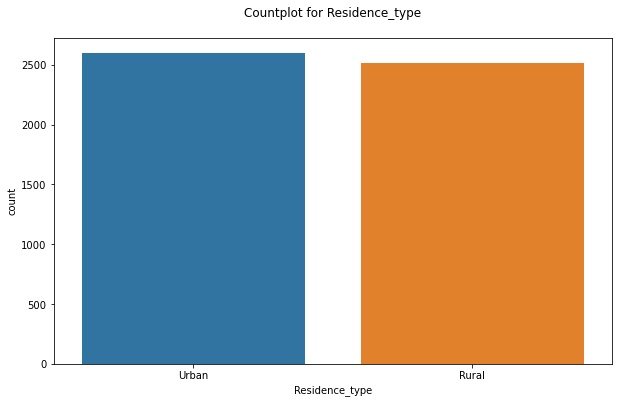

Urban    0.508023
Rural    0.491977
Name: Residence_type, dtype: float64

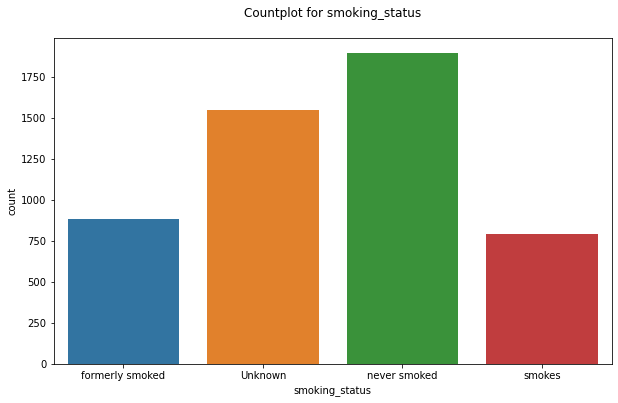

never smoked       0.370254
Unknown            0.302153
formerly smoked    0.173190
smokes             0.154403
Name: smoking_status, dtype: float64

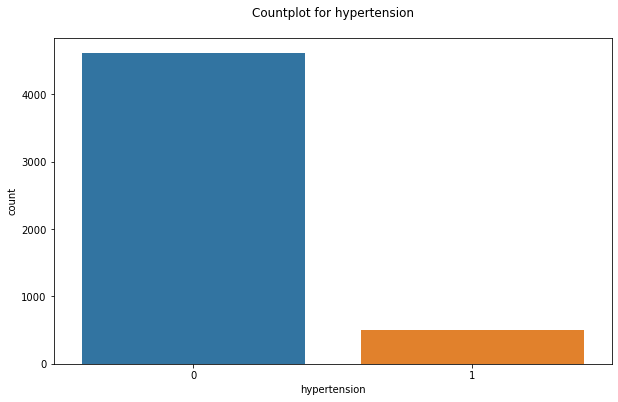

0    0.902544
1    0.097456
Name: hypertension, dtype: float64

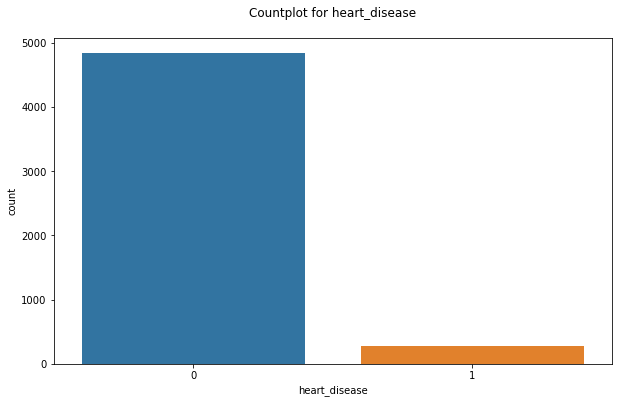

0    0.945988
1    0.054012
Name: heart_disease, dtype: float64

In [8]:
for col in cat_f:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'Countplot for {col}\n')
    sns.countplot(x=col, data=data)
    plt.show()

    display(data[col].value_counts(normalize=True))

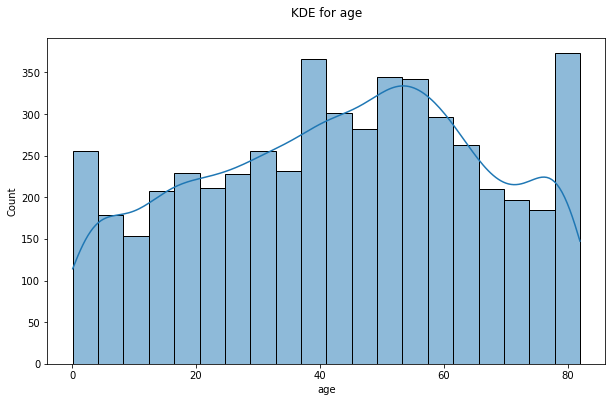

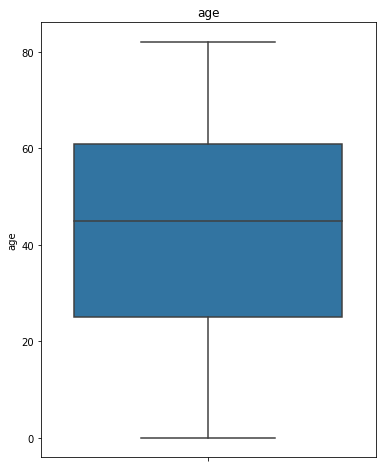

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

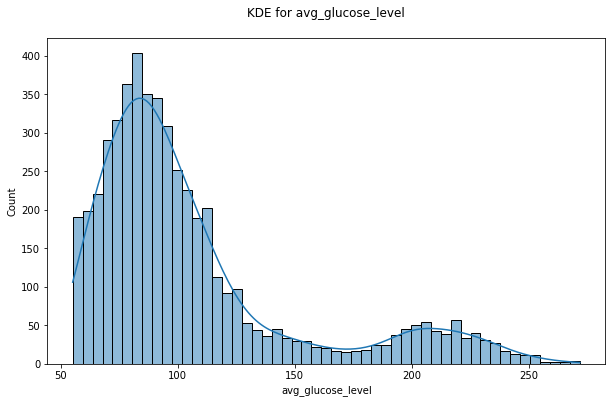

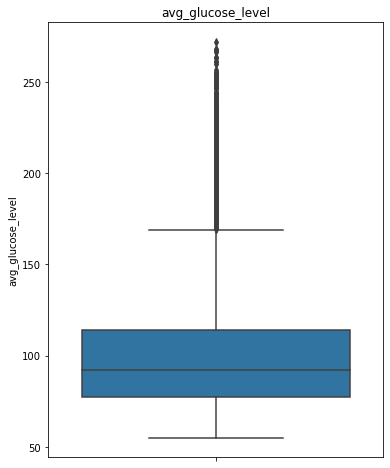

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

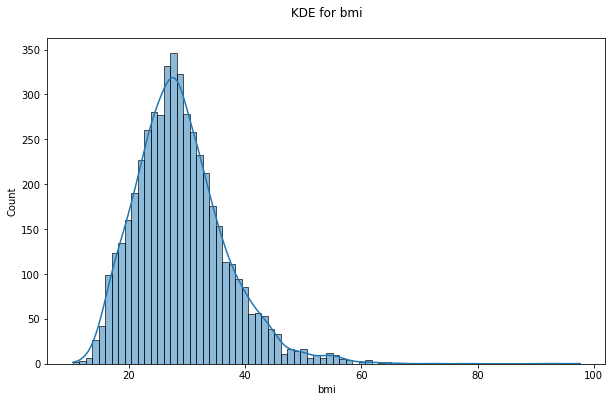

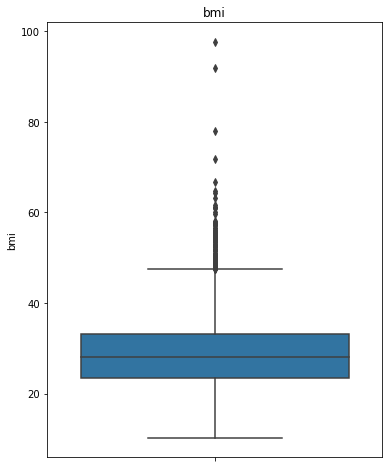

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [9]:
for col in con_f:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'KDE for {col}\n')
    sns.histplot(x=col, data=data, kde=True)
    plt.show()

    plt.figure(figsize=(6, 8))
    plt.title(col)
    sns.boxplot(y=col, data=data)
    plt.show()

    display(data[col].describe())

# bivariate analysis

<br>

In [10]:
pd.crosstab(data['gender'], data['stroke'])

stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


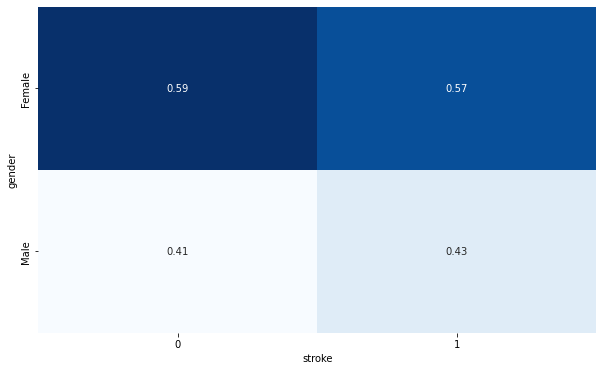

In [11]:

crosstab = pd.crosstab(data['gender'], data['stroke'], normalize='columns').drop(index='Other')
plt.figure(figsize=FIGSIZE)
sns.heatmap(crosstab, annot=True, cmap='Blues', cbar=False)
plt.show()

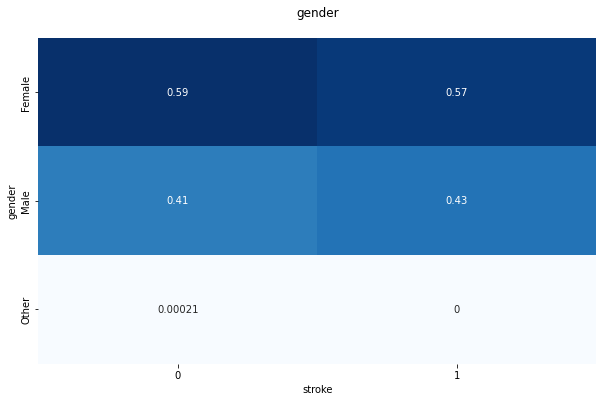

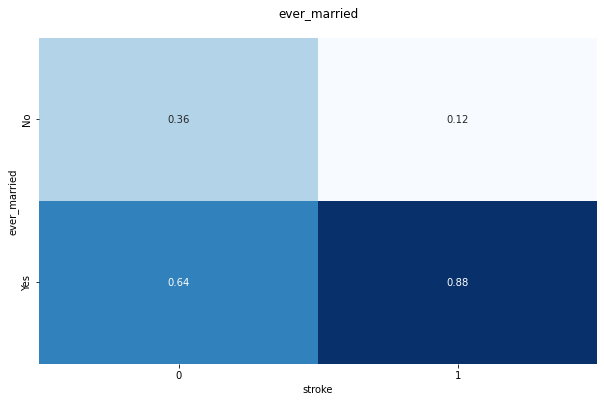

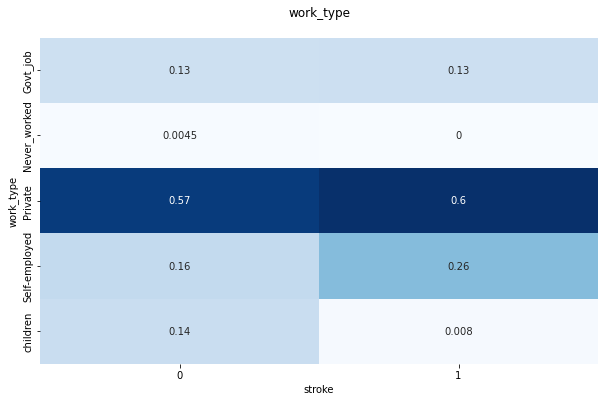

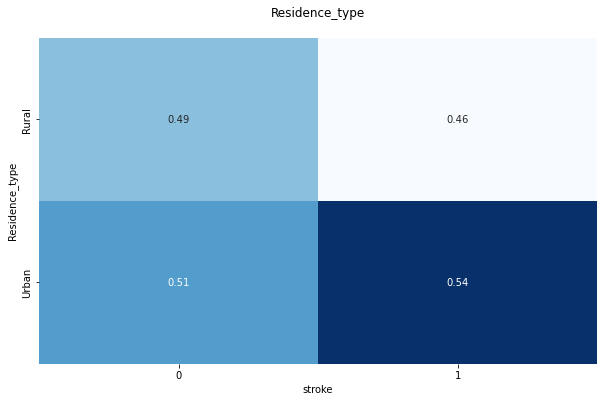

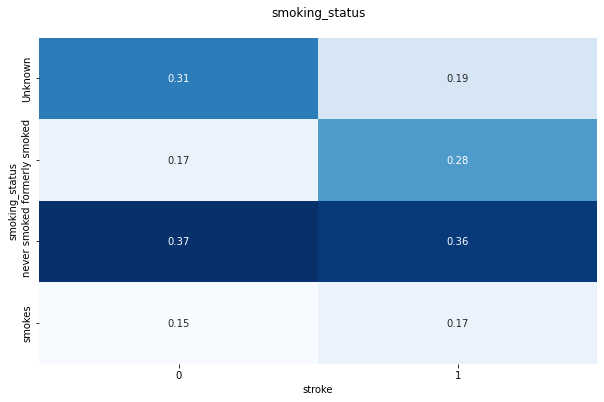

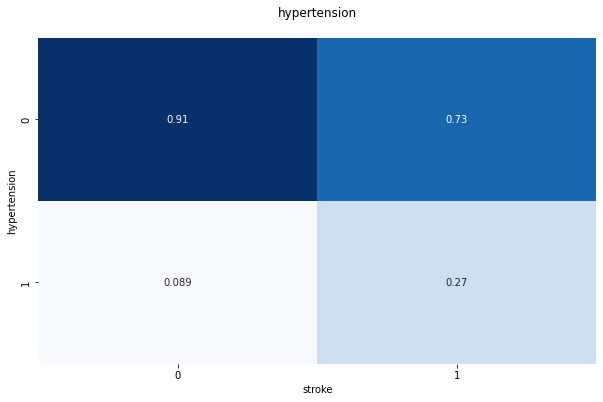

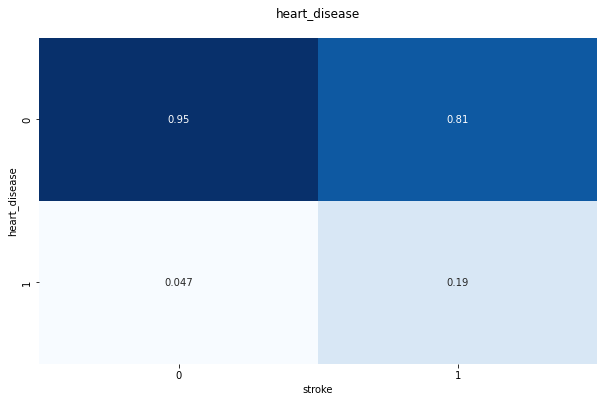

In [12]:
for col in cat_f:
    crosstab = pd.crosstab(data[col], data['stroke'], normalize='columns')
    plt.figure(figsize=FIGSIZE)
    plt.title(col+'\n')
    sns.heatmap(crosstab, annot=True, cmap='Blues', cbar=False)
    plt.show()
    

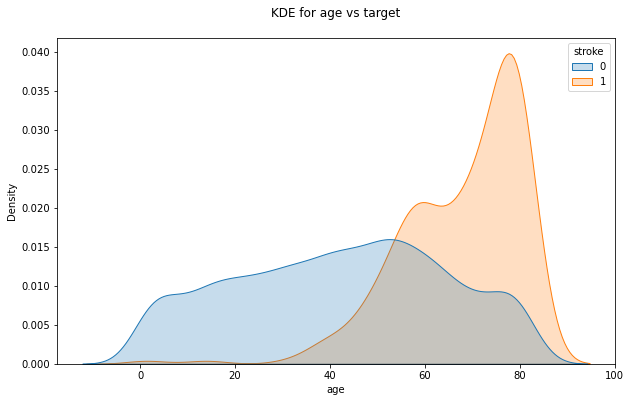

age                                                    
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4861.0  41.971545  22.291940  0.08  24.0  43.0  59.0  82.0
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0

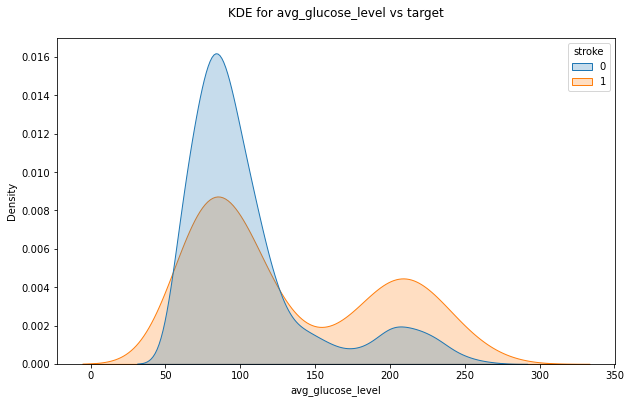

avg_glucose_level                                                       \
                   count        mean        std    min    25%     50%     75%   
stroke                                                                          
0                 4861.0  104.795513  43.846069  55.12  77.12   91.47  112.83   
1                  249.0  132.544739  61.921056  56.11  79.79  105.22  196.71   

                
           max  
stroke          
0       267.76  
1       271.74

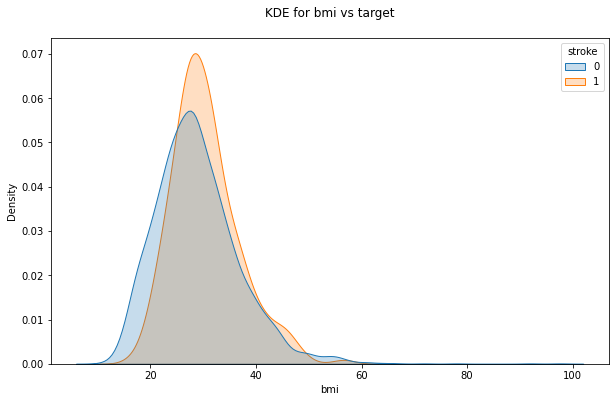

bmi                                                   
         count       mean       std   min   25%   50%   75%   max
stroke                                                           
0       4700.0  28.823064  7.908287  10.3  23.4  28.0  33.1  97.6
1        209.0  30.471292  6.329452  16.9  26.4  29.7  33.7  56.6

In [13]:
for col in con_f:
    plt.figure(figsize=FIGSIZE)
    plt.title(f'KDE for {col} vs target\n')
    sns.kdeplot(x=col, data=data, hue='stroke', fill=True, common_norm=False)
    plt.show()

    display(data[[col, 'stroke']].groupby('stroke').describe())

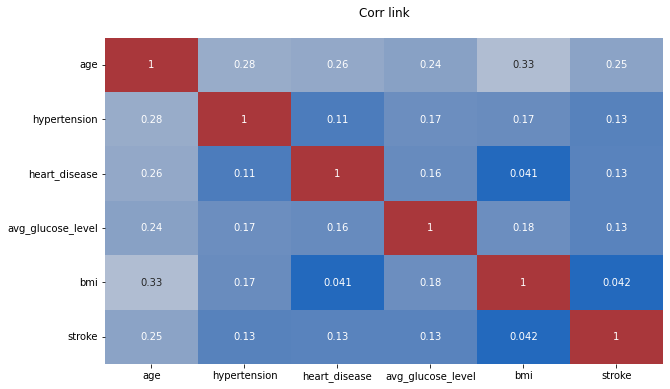

In [14]:
plt.figure(figsize=FIGSIZE)
plt.title('Corr link\n')
sns.heatmap(data.corr(), annot=True, cmap='vlag', cbar=False)
plt.show()

In [15]:
data['stroke'].value_counts()

0    4861
1     249
Name: stroke, dtype: int64

In [16]:
data_resampled = data[data['stroke'] == 1]
data_resampled = pd.concat([data_resampled,data[data['stroke'] == 0].sample(249, random_state=1)])
data_resampled['stroke'].value_counts()

1    249
0    249
Name: stroke, dtype: int64

In [17]:
# f_one_way ANOVA # Analysis of variance
# Hypothèse nulle H0 => pas différence significative entre les moyennes comparées
# punc==pvalue
# taille de l'effet => effect_size # degree of liberty
# 5%, 2.5%, 1% # cross validation/bootstrapping
pg.anova(data=data_resampled, dv='age', between='stroke')

,Source,ddof1,ddof2,F,p-unc,np2
0,stroke,1,496,246.155843,2.446533e-45,0.331677


In [18]:
# distribution normale => kruskal wallis => Non paramétrique
# homogénéité des variances => welch anova

In [19]:
pg.normality(data=data_resampled, dv='age', group='stroke')

,W,pval,normal
1,0.878133,3.173771e-13,False
0,0.958817,1.512113e-06,False


In [20]:
pg.homoscedasticity(data=data_resampled, dv='age', group='stroke')

,W,pval,equal_var
levene,120.920444,2.552477e-25,False


In [21]:
pg.welch_anova(data=data_resampled, dv='age', between='stroke')

,Source,ddof1,ddof2,F,p-unc,np2
0,stroke,1,383.147579,246.155843,3.381093e-43,0.331677


In [27]:
for col in data_resampled.select_dtypes(float):
    print(col)
    display(pg.welch_anova(data=data_resampled, dv=col, between='stroke'))
    print('\n')

age


,Source,ddof1,ddof2,F,p-unc,np2
0,stroke,1,383.147579,246.155843,3.381093e-43,0.331677




avg_glucose_level


,Source,ddof1,ddof2,F,p-unc,np2
0,stroke,1,415.299282,53.261358,1.496597e-12,0.096969




bmi


,Source,ddof1,ddof2,F,p-unc,np2
0,stroke,1,450.532442,5.749819,0.016896,0.012355


In [36]:
# pg.chi2_independence chi2 contingency
for col in cat_f:
    print(col)
    result = pg.chi2_independence(data=data, x=col, y='stroke')
    display(result[0]) # fréquences attendues
    display(result[1]) # fréquences observées
    display(result[2]) # résultats du test
    print('\n')

gender


C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn('Low count on {} frequencies.'.format(name))
C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on expected frequencies.
  warnings.warn('Low count on {} frequencies.'.format(name))
C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\scipy\stats\stats.py:6716: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\scipy\stats\stats.py:6716: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\Users\romain\anaconda3\envs\base_env\lib\site-packages\scipy\stats\stats.py:6713: RuntimeWarning: divide by zero encountered in true_divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


stroke,0,1
gender,,
Female,2848.108415,145.891585
Male,2011.940313,103.059687
Other,0.951272,0.048728


stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,0.472587,2.0,0.789549,0.009617,0.087313
1,cressie-read,0.666667,0.481696,2.0,0.785961,0.009709,0.088067
2,log-likelihood,0.000000,0.519447,2.0,0.771265,0.010082,0.091203
3,freeman-tukey,-0.500000,NaN,2.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,2.0,0.000000,inf,1.000000
5,neyman,-2.000000,NaN,2.0,NaN,NaN,NaN


...

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,81.605368,1.0,1.661622e-19,0.126371,1.000000
1,cressie-read,0.666667,72.922988,1.0,1.348088e-17,0.119460,1.000000
2,log-likelihood,0.000000,59.769802,1.0,1.066269e-14,0.108151,1.000000
3,freeman-tukey,-0.500000,52.612863,1.0,4.062199e-13,0.101469,1.000000
4,mod-log-likelihood,-1.000000,47.113056,1.0,6.700785e-12,0.096020,1.000000
5,neyman,-2.000000,39.537634,1.0,3.217978e-10,0.087962,0.999992




heart_disease


stroke,0,1
heart_disease,,
0,4598.448924,235.551076
1,262.551076,13.448924


stroke,0,1
heart_disease,,
0,4631.5,202.5
1,229.5,46.5


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,90.259561,1.0,2.088785e-21,0.132903,1.000000
1,cressie-read,0.666667,77.193504,1.0,1.550025e-18,0.122908,1.000000
2,log-likelihood,0.000000,58.724436,1.0,1.813748e-14,0.107201,1.000000
3,freeman-tukey,-0.500000,49.412060,1.0,2.074663e-12,0.098335,1.000000
4,mod-log-likelihood,-1.000000,42.639610,1.0,6.581308e-11,0.091347,0.999998
5,neyman,-2.000000,33.882000,1.0,5.855798e-09,0.081428,0.999944
